<a href="https://colab.research.google.com/github/malakbayramovaa/Machine-Learning/blob/main/hr_employees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('/content/aug_train.csv')
df

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,7386,city_173,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14,NaN,NaN,1,42,1.0
19154,31398,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14,NaN,NaN,4,52,1.0
19155,24576,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,4,44,0.0
19156,5756,city_65,0.802,Male,Has relevent experience,no_enrollment,High School,NaN,<1,500-999,Pvt Ltd,2,97,0.0


men bele basa dusdum ki bu dataset işçilər barədə bizə məlumat verir. Hanşı şəhərdəndirlər, cinsi nədir işçinin, təcrübəsi, university degree barədə məlumat görürəm. eyni zamanda iş təcrübəsi, işlədiyi şirkətin işçi sayı, işlədiyi saatlar, və mən belə başa düşdüm ki target sütunumuzda olan məlumat bizə işçinin işini dəyişib-dəyişmək istəmədiyi barədə məlumat verir.

* 1 - dəyişmək istəyir

* 0 - qalmaq istəyir.

In [ ]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [ ]:
df.describe()

,enrollee_id,city_development_index,training_hours,target
count,19158.000000,19158.000000,19158.000000,19158.000000
mean,16875.358179,0.828848,65.366896,0.249348
std,9616.292592,0.123362,60.058462,0.432647
min,1.000000,0.448000,1.000000,0.000000
25%,8554.250000,0.740000,23.000000,0.000000
50%,16982.500000,0.903000,47.000000,0.000000
75%,25169.750000,0.920000,88.000000,0.000000
max,33380.000000,0.949000,336.000000,1.000000


In [ ]:
df.shape

(19158, 14)

In [ ]:
df.columns

Index(['enrollee_id', 'city', 'city_development_index', 'gender',
       'relevent_experience', 'enrolled_university', 'education_level',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'last_new_job', 'training_hours', 'target'],
      dtype='object')

In [ ]:
df.dtypes

,0
enrollee_id,int64
city,object
city_development_index,float64
gender,object
relevent_experience,object
enrolled_university,object
education_level,object
major_discipline,object
experience,object
company_size,object


data tiplərini yoxladıqda görürəm ki əslində bəzi numeric olmalı olan sütunları categoric (object) kimi göstərilir.
 Buna səbəb də böyükdür, kiçikdir işarələridir. Onları da düzəltməliyəm daha sonra NaN dəyərləri doldurmalıyam.

In [ ]:
df.isnull().sum()

,0
enrollee_id,0
city,0
city_development_index,0
gender,4508
relevent_experience,0
enrolled_university,386
education_level,460
major_discipline,2813
experience,65
company_size,5938


yuxarıda hər sütun üzrə null dəyərlərə baxdım və görürəm ki hamısı sütunun 50%-dən aşağıdır. Bu null dəyərləri tam çıxartmağı düzgün hesab etmirəm. birde burada gender sütununda 4508 null dəyərin hamısını ən çox təkrrarlanan ilə əvəz etmək istəmirəm, çünki həmin dəyər hədsiz çox şişər deyə narahatam. (Eyni problemi company_type, major_discipline sutunlarinda da gordum.)İlk əvvəl "Bilinmir" kimi qoyacam daha sonra lazımsız olsa silərəm ya əvəz edərəm.
Amma ilk əvvəl mənim üçün lazım olmayacaq sütunları silmək istəyirəm datasetdən.

In [ ]:
df.drop(columns = ['enrollee_id'], axis=1, inplace = True)
df

# burada "id" olan sutun menim ucun hec bir mena vermirdi
#  burada yuksek faizli olan sutun bizim ucun hemin seherde daha yuksek memnun yasayis oldugunu deyir.

,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,city_173,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14,NaN,NaN,1,42,1.0
19154,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14,NaN,NaN,4,52,1.0
19155,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,4,44,0.0
19156,city_65,0.802,Male,Has relevent experience,no_enrollment,High School,NaN,<1,500-999,Pvt Ltd,2,97,0.0


In [ ]:
df[['gender', 'company_type', 'major_discipline']] = df[['gender', 'company_type', 'major_discipline']].fillna("Unknown")

In [ ]:
df.isnull().sum()

,0
city,0
city_development_index,0
gender,0
relevent_experience,0
enrolled_university,386
education_level,460
major_discipline,0
experience,65
company_size,5938
company_type,0


In [ ]:
df.head()

,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,Unknown,1,36,1.0
1,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,city_21,0.624,Unknown,No relevent experience,Full time course,Graduate,STEM,5,NaN,Unknown,never,83,0.0
3,city_115,0.789,Unknown,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [ ]:
df['experience'].value_counts().reset_index()

,experience,count
0,>20,3286
1,5,1430
2,4,1403
3,3,1354
4,6,1216
5,2,1127
6,7,1028
7,10,985
8,9,980
9,8,802


In [ ]:
df.head()

,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,Unknown,1,36,1.0
1,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,city_21,0.624,Unknown,No relevent experience,Full time course,Graduate,STEM,5,NaN,Unknown,never,83,0.0
3,city_115,0.789,Unknown,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [ ]:
df['experience'] = df['experience'].replace({'>20': 21,
                                             '<1':0.5}).astype(float)

In [ ]:
# is tecrubeleri ucun qruplar yaradacam.

araliqlar = [0, 1, 5, 10, 20, np.inf]
is_tecrubesi = ['tecrubesiz', 'junior', 'middle', 'senior', 'lead']
df['is_tecrubeleri'] = pd.cut(df['experience'], bins=araliqlar, labels=is_tecrubesi)
df['is_tecrubeleri']

,is_tecrubeleri
0,lead
1,senior
2,junior
3,tecrubesiz
4,lead
...,...
19153,senior
19154,senior
19155,lead
19156,tecrubesiz


In [ ]:
# her is tecrubeleri ucun saya baxaq

df['is_tecrubeleri'].value_counts().reset_index()

,is_tecrubeleri,count
0,junior,5314
1,middle,5011
2,senior,4411
3,lead,3286
4,tecrubesiz,1071


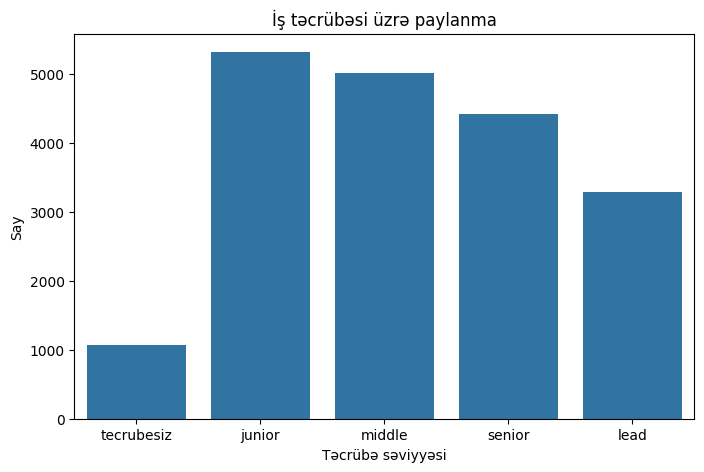

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='is_tecrubeleri', data=df, order=['tecrubesiz','junior','middle','senior','lead'])

plt.title('İş təcrübəsi üzrə paylanma')
plt.xlabel('Təcrübə səviyyəsi')
plt.ylabel('Say')
plt.show()

In [ ]:
df['last_new_job'].value_counts().reset_index()

,last_new_job,count
0,1,8040
1,>4,3290
2,2,2900
3,never,2452
4,4,1029
5,3,1024


In [ ]:
df['last_new_job'] = df['last_new_job'].replace({'>4':5,
                                                 'never':0}).astype(float)

In [ ]:
df.dtypes

,0
city,object
city_development_index,float64
gender,object
relevent_experience,object
enrolled_university,object
education_level,object
major_discipline,object
experience,float64
company_size,object
company_type,object


In [ ]:
df['company_size'].value_counts().reset_index()

,company_size,count
0,50-99,3083
1,100-500,2571
2,10000+,2019
3,10/49,1471
4,1000-4999,1328
5,<10,1308
6,500-999,877
7,5000-9999,563


In [ ]:
import numpy as np
import pandas as pd

def convert_size(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip()

    if x == '10000+':
        return 12000

    elif x == '<10':
        return 5  # midpoint kimi

    elif x == '10/49':
        return (10 + 49) / 2

    elif x == '50-99':
        return (50 + 99) / 2

    elif x == '100-500':
        return (100 + 500) / 2

    elif x == '500-999':
        return (500 + 999) / 2

    elif x == '1000-4999':
        return (1000 + 4999) / 2

    elif x == '5000-9999':
        return (5000 + 9999) / 2

    else:
        return np.nan

Demeli men yuxaridaki kodda null deyerleri oldugu kimi saxladim amma diger isareleri, araliq kimi verilen deyerleri evez etdim. Data tipi de duzelsin melumatlari da oxuya bilsin model.

In [ ]:
df['company_size'] = df['company_size'].apply(convert_size)

In [ ]:
df['company_size'].value_counts().reset_index()

,company_size,count
0,74.5,3083
1,300.0,2571
2,12000.0,2019
3,29.5,1471
4,2999.5,1328
5,5.0,1308
6,749.5,877
7,7499.5,563


In [ ]:
df.dtypes

,0
city,object
city_development_index,float64
gender,object
relevent_experience,object
enrolled_university,object
education_level,object
major_discipline,object
experience,float64
company_size,float64
company_type,object


In [ ]:
df.isnull().sum()

,0
city,0
city_development_index,0
gender,0
relevent_experience,0
enrolled_university,386
education_level,460
major_discipline,0
experience,65
company_size,5938
company_type,0


In [ ]:
# indi burada null deyerleri doldura bilerik. evvelce numeric ve categoric sutunlari ayiracam

categoric_cols = df.select_dtypes(include = 'object').columns
categoric_cols

Index(['city', 'gender', 'relevent_experience', 'enrolled_university',
       'education_level', 'major_discipline', 'company_type'],
      dtype='object')

In [ ]:
numeric_cols = df.select_dtypes(include = np.number).columns
numeric_cols

Index(['city_development_index', 'experience', 'company_size', 'last_new_job',
       'training_hours', 'target'],
      dtype='object')

In [ ]:
df.head()

,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,is_tecrubeleri
0,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,21.0,NaN,Unknown,1.0,36,1.0,lead
1,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,74.5,Pvt Ltd,5.0,47,0.0,senior
2,city_21,0.624,Unknown,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,Unknown,0.0,83,0.0,junior
3,city_115,0.789,Unknown,No relevent experience,NaN,Graduate,Business Degree,0.5,NaN,Pvt Ltd,0.0,52,1.0,tecrubesiz
4,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,21.0,74.5,Funded Startup,4.0,8,0.0,lead


In [ ]:
for column in categoric_cols:
  df[column] = df[column].fillna(df[column].mode()[0])

In [ ]:
for column in numeric_cols:
  df[column] = df[column].fillna(df[column].median())

In [ ]:
df.isnull().sum()

,0
city,0
city_development_index,0
gender,0
relevent_experience,0
enrolled_university,0
education_level,0
major_discipline,0
experience,0
company_size,0
company_type,0


goruruk ki null deyerler de her biri dolduruldu sadece unknown olan deyerler qalib onlari helelik saxlayacaq cunki dataseti cox menasiz deyerlerle doldurub bir deyeri cox sisirtmek istemedim.

In [ ]:
df

,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,is_tecrubeleri
0,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,21.0,300.0,Unknown,1.0,36,1.0,lead
1,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,74.5,Pvt Ltd,5.0,47,0.0,senior
2,city_21,0.624,Unknown,No relevent experience,Full time course,Graduate,STEM,5.0,300.0,Unknown,0.0,83,0.0,junior
3,city_115,0.789,Unknown,No relevent experience,no_enrollment,Graduate,Business Degree,0.5,300.0,Pvt Ltd,0.0,52,1.0,tecrubesiz
4,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,21.0,74.5,Funded Startup,4.0,8,0.0,lead
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,city_173,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14.0,300.0,Unknown,1.0,42,1.0,senior
19154,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14.0,300.0,Unknown,4.0,52,1.0,senior
19155,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,21.0,74.5,Pvt Ltd,4.0,44,0.0,lead
19156,city_65,0.802,Male,Has relevent experience,no_enrollment,High School,Unknown,0.5,749.5,Pvt Ltd,2.0,97,0.0,tecrubesiz


In [ ]:
df.groupby('gender')['training_hours'].median()

,training_hours
gender,
Female,49.0
Male,47.0
Other,45.0
Unknown,46.0


<Axes: xlabel='experience', ylabel='education_level'>

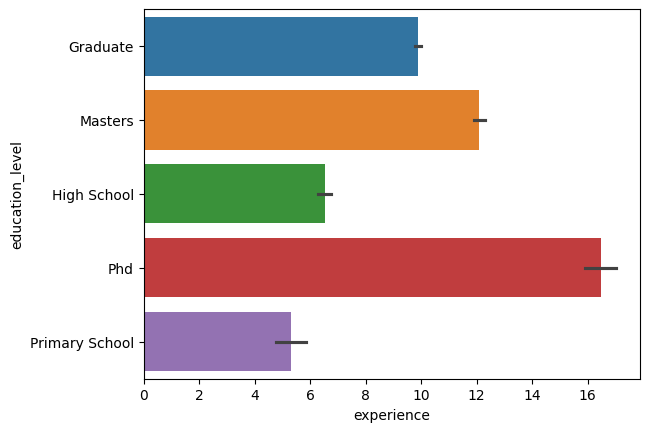

In [ ]:
import seaborn as sns
sns.barplot(df, x="experience", y="education_level", hue="education_level", legend=False)

In [ ]:
df['relevent_experience'].value_counts().reset_index()

,relevent_experience,count
0,Has relevent experience,13792
1,No relevent experience,5366


<Axes: >

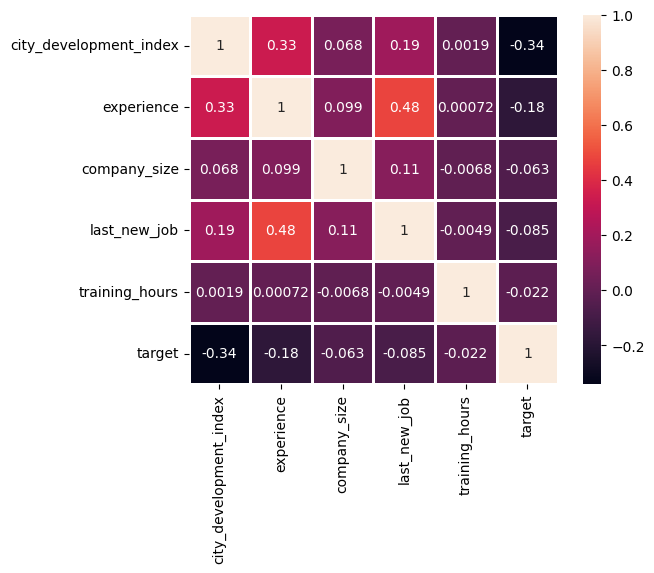

In [ ]:
# numeric sutunlarin bir biri ile elaqesi baxdim.
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, square = True, linewidths = 1)

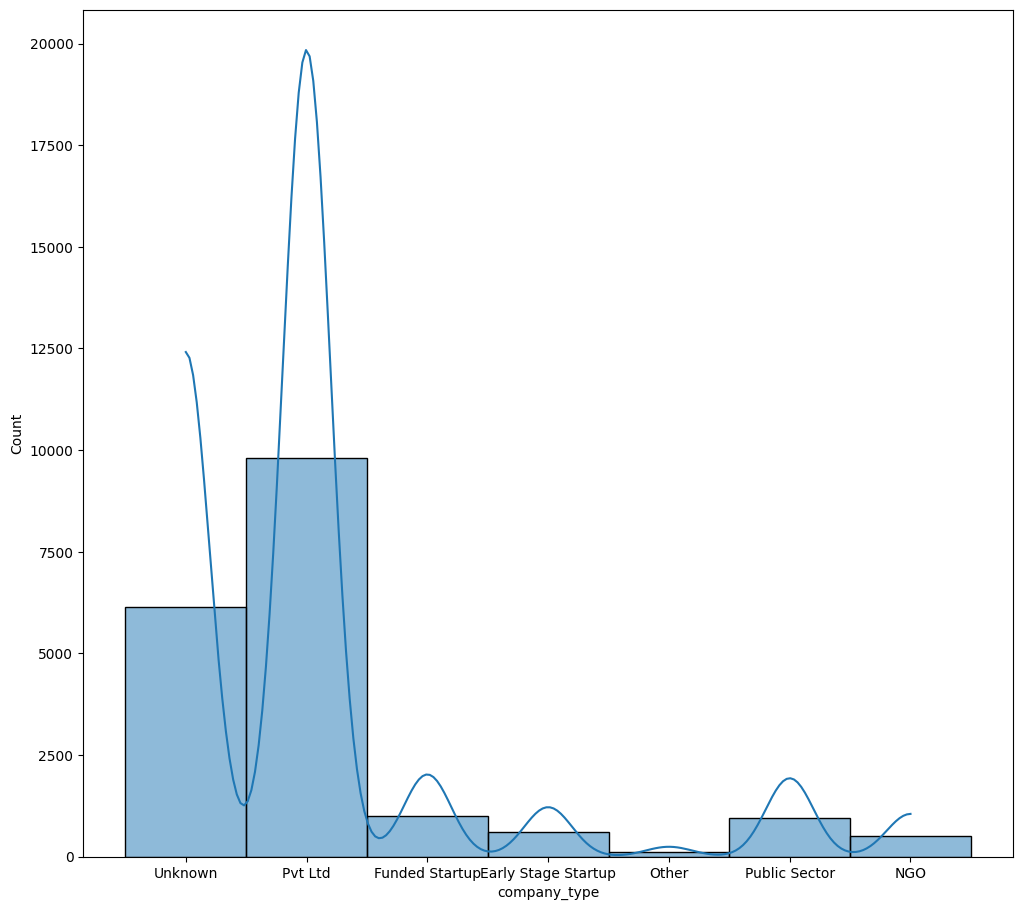

In [ ]:
#  her sirket novu uzre ne qeder isci var sayina baxdim.
import matplotlib.pyplot as plt
plt.figure(figsize=(12,11))
sns.histplot(df,x='company_type', kde=True, legend=True);

<Axes: xlabel='training_hours', ylabel='Count'>

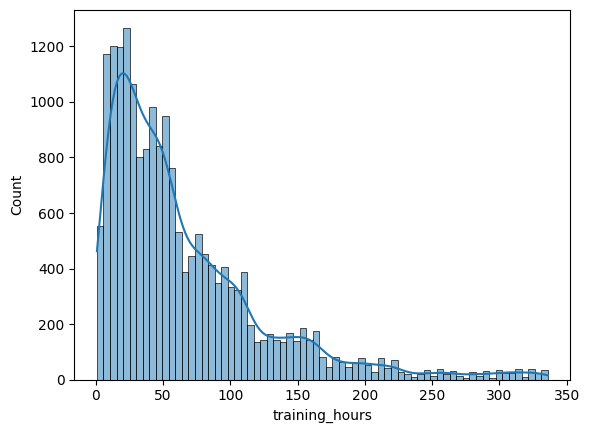

In [ ]:
sns.histplot(df['training_hours'], kde=True)

<Axes: xlabel='training_hours'>

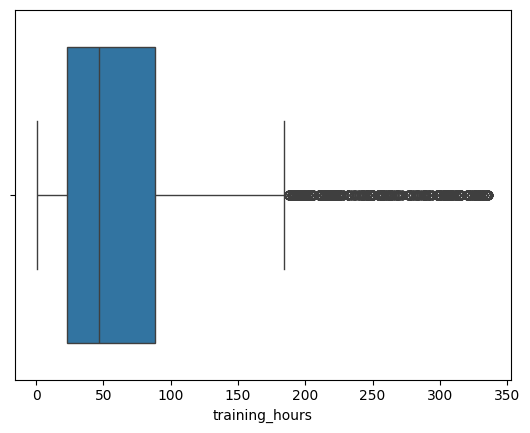

In [ ]:
sns.boxplot(x=df['training_hours'])

<Axes: xlabel='target', ylabel='training_hours'>

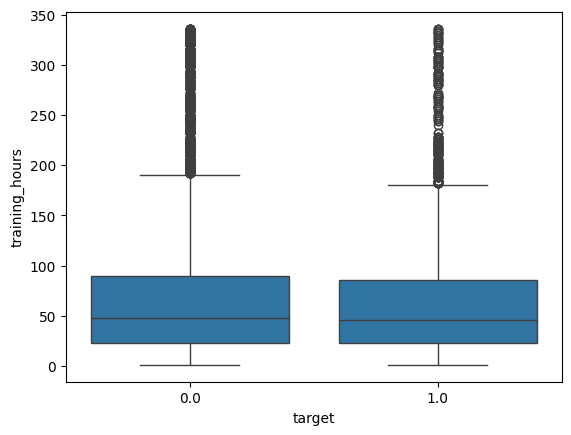

In [ ]:
sns.boxplot(x='target', y='training_hours', data=df)

"training_hours" sutununda cox outliers gorurem men.  temizlesem melumat itirecem. ona gore hele saxlamaq isteyirem.

In [ ]:
df.describe()

,city_development_index,experience,company_size,last_new_job,training_hours,target
count,19158.000000,19158.000000,19158.000000,19158.000000,19158.000000,19158.000000
mean,0.828848,10.110032,1875.100950,1.978338,65.366896,0.249348
std,0.123362,6.745949,3742.130556,1.663502,60.058462,0.432647
min,0.448000,0.500000,5.000000,0.000000,1.000000,0.000000
25%,0.740000,4.000000,74.500000,1.000000,23.000000,0.000000
50%,0.903000,9.000000,300.000000,1.000000,47.000000,0.000000
75%,0.920000,16.000000,300.000000,3.000000,88.000000,0.000000
max,0.949000,21.000000,12000.000000,5.000000,336.000000,1.000000


<Axes: xlabel='company_size'>

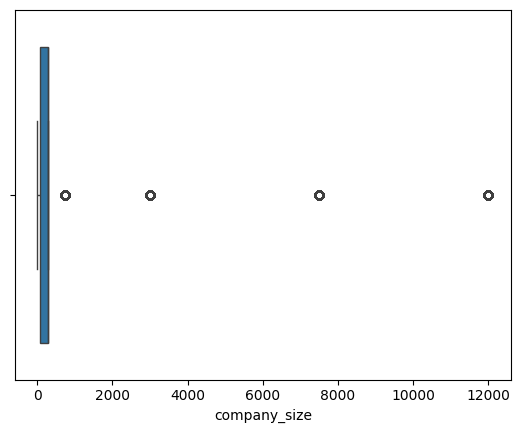

In [ ]:
#  men burada fikir verdim ki company_size sutununda da outliers gorunur.
# ona da boxplot ile baxacam

sns.boxplot(x=df['company_size'])

# hee burada daha azdir.

In [ ]:
# yene de outliers sayina baxmaq istedim.
for i in numeric_cols:
  Q1 = df[i].quantile(0.25)
  Q3 = df[i].quantile(0.75)
  IQR = Q3 - Q1

  asagi_hedd = Q1 - (1.5*IQR)
  yuxari_hedd = Q3 + (1.5*IQR)

  outliers = df[(df[i] <= asagi_hedd ) | (df[i] >= yuxari_hedd)]
  print(f"{i} - outliers count: {len(outliers)}")

city_development_index - outliers count: 17
experience - outliers count: 0
company_size - outliers count: 4787
last_new_job - outliers count: 0
training_hours - outliers count: 984
target - outliers count: 19158


In [ ]:
df['city'].value_counts()

,count
city,
city_103,4355
city_21,2702
city_16,1533
city_114,1336
city_160,845
...,...
city_111,3
city_129,3
city_121,3


In [ ]:
top_5_city = df['city'].value_counts().head(5).reset_index()
top_5_city

,city,count
0,city_103,4355
1,city_21,2702
2,city_16,1533
3,city_114,1336
4,city_160,845


In [ ]:
top_5_city_names = top_5_city['city'].tolist()
df[df['city'].isin(top_5_city_names)].groupby('city')['city_development_index'].mean().reset_index()

,city,city_development_index
0,city_103,0.920
1,city_114,0.926
2,city_16,0.910
3,city_160,0.920
4,city_21,0.624


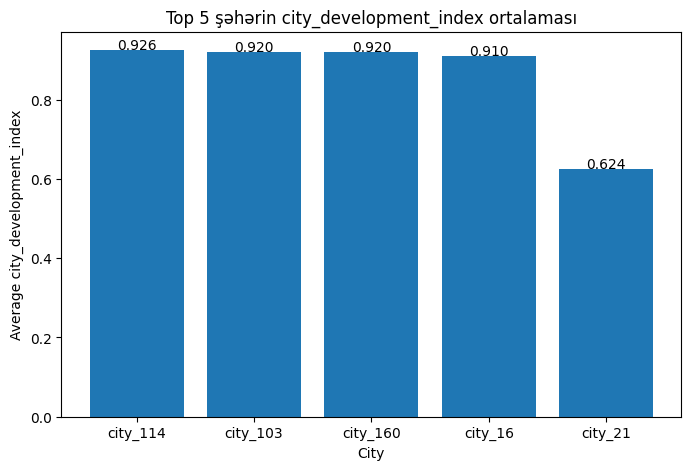

In [ ]:
city_dev = (df[df['city'].isin(top_5_city_names)].groupby('city')['city_development_index'].mean().reset_index()
    .sort_values(by='city_development_index', ascending=False)
)

plt.figure(figsize=(8,5))
plt.bar(city_dev['city'], city_dev['city_development_index'])
plt.xlabel('City')
plt.ylabel('Average city_development_index')
plt.title('Top 5 şəhərin city_development_index ortalaması')
for i, v in enumerate(city_dev['city_development_index']):
    plt.text(i, v + 0.002, f"{v:.3f}", ha='center')

plt.show()

hee "company_size" ve "training_hours" sutunlarinda olanlari gormusdum. "target" sutunu da melum yalniz 1 ve 0-dan ibaret oldugu ucun hamisini outliers kimi gosterir. "city_development_index" sutununda da var amma dehset cox azdir ve temizlemek istemirem.

In [ ]:
df['education_level'].value_counts().reset_index()

,education_level,count
0,Graduate,12058
1,Masters,4361
2,High School,2017
3,Phd,414
4,Primary School,308


In [ ]:
df['relevent_experience'].value_counts().reset_index()

# indii isteyirem ki encodingden istifade edim datasetde olan categoric deyisenleri numeric kimi edim.

# buna ona gore baxdim ki deyerler necedir gorurem ki tecrubesi var ve yoxdur kimi ayrilib men burada tecrubesi olanlara 1 deyecem,
#  olmayanlara ise 0 deyecem encodingde mappingden istifade edeceyem.

df['relevent_experience'] = df['relevent_experience'].map({'Has relevent experience':1,
                                                           'No relevent experience':0})
df['education_level'] = df['education_level'].map({"Primary School":0,
                                                   "High School":1,
                                                   "Graduate":2,
                                                   "Masters":3,
                                                   "Phd": 4})


In [ ]:
df = pd.get_dummies(df, columns = ['gender', 'enrolled_university', 'major_discipline', 'company_type'], dtype='int')
df.head()

,city,city_development_index,relevent_experience,education_level,experience,company_size,last_new_job,training_hours,target,is_tecrubeleri,...,major_discipline_Other,major_discipline_STEM,major_discipline_Unknown,company_type_Early Stage Startup,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,company_type_Unknown
0,city_103,0.920,1,2,21.0,300.0,1.0,36,1.0,lead,...,0,1,0,0,0,0,0,0,0,1
1,city_40,0.776,0,2,15.0,74.5,5.0,47,0.0,senior,...,0,1,0,0,0,0,0,0,1,0
2,city_21,0.624,0,2,5.0,300.0,0.0,83,0.0,junior,...,0,1,0,0,0,0,0,0,0,1
3,city_115,0.789,0,2,0.5,300.0,0.0,52,1.0,tecrubesiz,...,0,0,0,0,0,0,0,0,1,0
4,city_162,0.767,1,3,21.0,74.5,4.0,8,0.0,lead,...,0,1,0,0,1,0,0,0,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 31 columns):
 #   Column                                Non-Null Count  Dtype   
---  ------                                --------------  -----   
 0   city                                  19158 non-null  object  
 1   city_development_index                19158 non-null  float64 
 2   relevent_experience                   19158 non-null  int64   
 3   education_level                       19158 non-null  int64   
 4   experience                            19158 non-null  float64 
 5   company_size                          19158 non-null  float64 
 6   last_new_job                          19158 non-null  float64 
 7   training_hours                        19158 non-null  int64   
 8   target                                19158 non-null  float64 
 9   is_tecrubeleri                        19093 non-null  category
 10  gender_Female                         19158 non-null  int64   
 11  ge

In [ ]:
# X ve y-a ayiracam daha sonra train_teste bolecem

X = df.drop(columns = 'target', axis=1)
y = df['target']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((15326, 30), (3832, 30), (15326,), (3832,))

dataset duzgun bolunub.